# Tahap pertama yakni memvisualisasi terlebih dahulu data yang di pakai 
## yakni tahapan normalisasi sinyal, visualisasi channel, filtering untuk menghilangkan frekuensi rendah yang tidak relevan, sengmentasi sinyal 
<p> Tahap pertama dalam penelitian ini adalah memvisualisasikan dan menyiapkan data EEG yang digunakan. Pada tahap ini dilakukan serangkaian proses awal untuk memastikan kualitas sinyal sebelum dianalisis lebih lanjut. Proses tersebut meliputi normalisasi sinyal guna menyamakan skala amplitudo antar channel, visualisasi channel untuk meninjau pola aktivitas serta mendeteksi adanya noise atau artefak, filtering untuk menghilangkan komponen frekuensi rendah yang tidak relevan seperti baseline drift di bawah 0.5 Hz, dan segmentasi sinyal untuk membagi data EEG menjadi potongan-potongan pendek agar lebih mudah diproses pada tahap analisis atau pelatihan model (Han et al., 2025; Xia et al., 2025; Xiong et al., 2024).

## berikut untuk analisis data dari EEGDenoiseNet

In [6]:
import os
import glob

folder_path = r'C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet'

# Cari semua file .mat dalam folder
mat_files = glob.glob(os.path.join(folder_path, "*.mat"))
print("File .mat yang ditemukan:")
for file in mat_files:
    print(f"📁 {file}")
    
if mat_files:
    # Load file .mat pertama
    import scipy.io
    data = scipy.io.loadmat(mat_files[2])
    print(f"\nKeys dalam file: {list(data.keys())}")

File .mat yang ditemukan:
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EEG_all_epochs.mat
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EMG_all_epochs.mat
📁 C:\Users\akip\Desktop\EEGdenoiseNet\Data EEGDenoiseNet\EOG_all_epochs.mat

Keys dalam file: ['__header__', '__version__', '__globals__', 'EOG_all_epochs', 'fs']


In [7]:
eeg_data = scipy.io.loadmat(f'{folder_path}/EEG_all_epochs.mat')
emg_data = scipy.io.loadmat(f'{folder_path}/EMG_all_epochs.mat')
eog_data = scipy.io.loadmat(f'{folder_path}/EOG_all_epochs.mat')
    
print("=== EEG DATA ===")
print(f"Keys: {list(eeg_data.keys())}")
print(f"EEG shape: {eeg_data['EEG_all_epochs'].shape if 'EEG_all_epochs' in eeg_data else 'Not found'}")
    
print("\n=== EMG DATA ===")
print(f"Keys: {list(emg_data.keys())}")
print(f"EMG shape: {emg_data['EMG_all_epochs'].shape if 'EMG_all_epochs' in emg_data else 'Not found'}")
    
print("\n=== EOG DATA ===")
print(f"Keys: {list(eog_data.keys())}")
print(f"EOG shape: {eog_data['EOG_all_epochs'].shape if 'EOG_all_epochs' in eog_data else 'Not found'}")
print(f"Sampling rate: {eog_data['fs'][0,0] if 'fs' in eog_data else 'Not found'}")


=== EEG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EEG_all_epochs', 'fs']
EEG shape: (4514, 512)

=== EMG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EMG_all_epochs', 'fs']
EMG shape: (5598, 512)

=== EOG DATA ===
Keys: ['__header__', '__version__', '__globals__', 'EOG_all_epochs', 'fs']
EOG shape: (3400, 512)
Sampling rate: 256


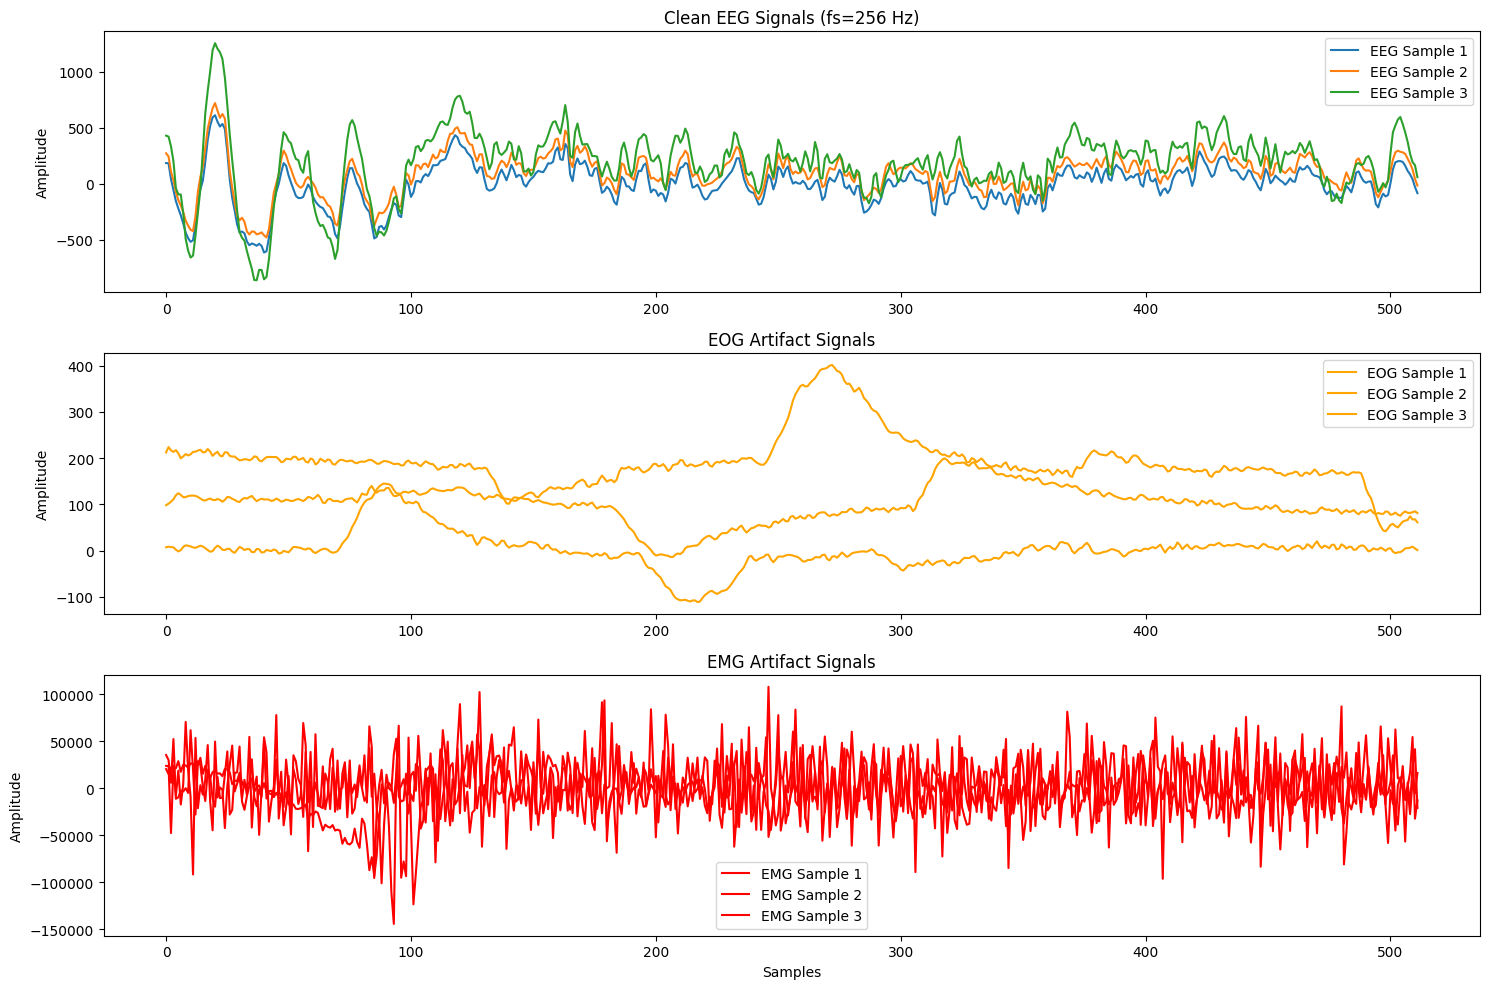

In [8]:
import matplotlib.pyplot as plt
def visualize_sample_data(eeg_data, emg_data, eog_data, num_samples=3):
    """Visualisasi contoh data dari setiap tipe"""
    
    fs = eog_data['fs'][0,0]  # Sampling rate
    
    plt.figure(figsize=(15, 10))
    
    # Plot EEG clean
    plt.subplot(3, 1, 1)
    if 'EEG_all_epochs' in eeg_data:
        eeg_samples = eeg_data['EEG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(eeg_samples[i] + i * 100, label=f'EEG Sample {i+1}')
        plt.title(f'Clean EEG Signals (fs={fs} Hz)')
        plt.ylabel('Amplitude')
        plt.legend()
    
    # Plot EOG artifacts
    plt.subplot(3, 1, 2)
    if 'EOG_all_epochs' in eog_data:
        eog_samples = eog_data['EOG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(eog_samples[i] + i * 100, label=f'EOG Sample {i+1}', color='orange')
        plt.title('EOG Artifact Signals')
        plt.ylabel('Amplitude')
        plt.legend()
    
    # Plot EMG artifacts
    plt.subplot(3, 1, 3)
    if 'EMG_all_epochs' in emg_data:
        emg_samples = emg_data['EMG_all_epochs'][:num_samples, :]
        for i in range(num_samples):
            plt.plot(emg_samples[i] + i * 100, label=f'EMG Sample {i+1}', color='red')
        plt.title('EMG Artifact Signals')
        plt.ylabel('Amplitude')
        plt.xlabel('Samples')
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Visualisasi data
visualize_sample_data(eeg_data, emg_data, eog_data)

In [11]:
import numpy as np
class EEGDenoisePreprocessor:
    def __init__(self, fs=256, segment_length=2, overlap=0.5):
        self.fs = fs
        self.segment_length = segment_length
        self.overlap = overlap
        self.samples_per_segment = int(segment_length * fs)
    
    def create_noisy_eeg(self, clean_eeg, artifact, snr_db=0):
        """Buat sinyal EEG noisy dengan SNR tertentu"""
        # Normalize power
        clean_power = np.mean(clean_eeg**2)
        artifact_power = np.mean(artifact**2)
        
        # Hindari division by zero
        if artifact_power == 0:
            artifact_power = 1e-10
            
        # Calculate scaling factor for desired SNR
        snr_linear = 10**(snr_db / 10)
        scale_factor = np.sqrt(clean_power / (artifact_power * snr_linear))
        
        # Create noisy signal
        noisy_eeg = clean_eeg + scale_factor * artifact
        return noisy_eeg
    
    def segment_data(self, signals):
        """Segmentasi sinyal dengan overlapping"""
        segments = []
        n_total = signals.shape[1]
        step_size = int(self.samples_per_segment * (1 - self.overlap))
        
        for start in range(0, n_total - self.samples_per_segment + 1, step_size):
            end = start + self.samples_per_segment
            segment = signals[:, start:end]
            segments.append(segment)
        
        return np.array(segments)
    
    def normalize(self, data):
        """Z-score normalization per channel"""
        # Untuk menghindari division by zero
        std = np.std(data, axis=-1, keepdims=True)
        std[std == 0] = 1e-10
        return (data - np.mean(data, axis=-1, keepdims=True)) / std
    
    def prepare_training_data(self, eeg_data, eog_data, emg_data, snr_levels=[-7, -4, 0, 4], max_samples=1000):
        """Siapkan data training untuk denoising"""
        
        clean_eeg = eeg_data['EEG_all_epochs']
        eog_artifacts = eog_data['EOG_all_epochs']
        emg_artifacts = emg_data['EMG_all_epochs']
        
        print(f"Clean EEG: {clean_eeg.shape}")
        print(f"EOG artifacts: {eog_artifacts.shape}")
        print(f"EMG artifacts: {emg_artifacts.shape}")
        
        # Batasi samples untuk testing
        n_samples = min(max_samples, len(clean_eeg), len(eog_artifacts), len(emg_artifacts))
        clean_eeg = clean_eeg[:n_samples]
        eog_artifacts = eog_artifacts[:n_samples]
        emg_artifacts = emg_artifacts[:n_samples]
        
        # Inisialisasi lists
        all_clean = []
        all_noisy = []
        
        # Generate noisy data untuk berbagai SNR dan artifact types
        for snr in snr_levels:
            print(f"Generating SNR {snr} dB...")
            
            # EOG contamination
            for i in range(len(clean_eeg)):
                noisy_eog = self.create_noisy_eeg(clean_eeg[i], eog_artifacts[i], snr)
                all_clean.append(clean_eeg[i])
                all_noisy.append(noisy_eog)
            
            # EMG contamination  
            for i in range(len(clean_eeg)):
                noisy_emg = self.create_noisy_eeg(clean_eeg[i], emg_artifacts[i], snr)
                all_clean.append(clean_eeg[i])
                all_noisy.append(noisy_emg)
        
        # Convert to arrays
        all_clean = np.array(all_clean)
        all_noisy = np.array(all_noisy)
        
        print(f"Total samples sebelum segmentasi: {all_clean.shape}")
        
        # Segmentasi
        clean_segments = self.segment_data(all_clean)
        noisy_segments = self.segment_data(all_noisy)
        
        print(f"Setelah segmentasi - Noisy: {noisy_segments.shape}, Clean: {clean_segments.shape}")
        
        # Normalisasi
        clean_segments = self.normalize(clean_segments)
        noisy_segments = self.normalize(noisy_segments)
        
        return noisy_segments, clean_segments

# Initialize preprocessor
preprocessor = EEGDenoisePreprocessor(fs=256, segment_length=2, overlap=0.5)

# Prepare data training (dengan samples terbatas untuk testing)
X_noisy, y_clean = preprocessor.prepare_training_data(eeg_data, eog_data, emg_data, max_samples=200)

Clean EEG: (4514, 512)
EOG artifacts: (3400, 512)
EMG artifacts: (5598, 512)
Generating SNR -7 dB...
Generating SNR -4 dB...
Generating SNR 0 dB...
Generating SNR 4 dB...
Total samples sebelum segmentasi: (1600, 512)
Setelah segmentasi - Noisy: (1, 1600, 512), Clean: (1, 1600, 512)


## Langkah mengindai artefak berdasarkan line frekuensi 
<p> Langkah mengindai artefak berdasarkan line frekuensi merupakan proses untuk mendeteksi gangguan periodik pada sinyal EEG yang disebabkan oleh interferensi listrik dari jaringan daya (biasanya 50 Hz atau 60 Hz). Pada tahap ini, analisis dilakukan pada domain frekuensi untuk mengidentifikasi komponen yang menunjukkan puncak tajam pada frekuensi tersebut. Deteksi ini penting karena artefak jenis ini dapat menurunkan kualitas sinyal dan mengganggu proses analisis. Setelah terdeteksi, gangguan tersebut biasanya dihilangkan menggunakan notch filter atau teknik spectral subtraction agar sinyal EEG tetap representatif terhadap aktivitas otak sebenarnya (Gabardi et al., 2024; Bellamkonda et al., 2025).

In [1]:
# Cell 1: Setup dan import
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy import signal
from pathlib import Path
import mne
from scipy.fft import fft, fftfreq
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100

print("✅ Libraries loaded for line noise detection!")

✅ Libraries loaded for line noise detection!


In [ ]:
# Explorasi file yang ada
def explore_dataset():
    """Explorasi semua file dalam dataset"""
    print("📁 EXPLORASI DATASET BCI COMPETITION IV")
    print("=" * 60)
    
    all_files = list(data_path.glob("*"))
    print(f"Total file ditemukan: {len(all_files)}")
    
    # Kelompokkan berdasarkan ekstensi
    file_types = {}
    for file in all_files:
        ext = file.suffix.lower()
        if ext not in file_types:
            file_types[ext] = []
        file_types[ext].append(file.name)
    
    print("\n📊 Breakdown by file type:")
    for ext, files in file_types.items():
        print(f"🔹 {ext}: {len(files)} files")
        for f in sorted(files)[:3]:  # Tampilkan 3 file pertama
            print(f"   - {f}")
    
    return file_types

# Jalankan explorasi
file_types = explore_dataset()

📁 EXPLORASI DATASET BCI COMPETITION IV
Total file ditemukan: 4

📊 Breakdown by file type:
🔹 : 4 files
   - dataset1
   - dataset2
   - dataset3


In [ ]:
# Cell 2: Fungsi utama deteksi line noise
def detect_line_noise(eeg_data, fs=250, line_freq=50, threshold_db=20):
    """
    Deteksi line frequency artifact pada sinyal EEG
    
    Parameters:
    - eeg_data: array EEG (channels x samples)
    - fs: sampling frequency
    - line_freq: frekuensi line noise (50 Hz atau 60 Hz)
    - threshold_db: threshold dalam dB untuk deteksi artifact
    """
    
    n_channels, n_samples = eeg_data.shape
    freqs = fftfreq(n_samples, 1/fs)
    
    # Region frekuensi sekitar line frequency
    freq_range = [line_freq-2, line_freq+2]
    freq_mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    results = {
        'has_line_noise': [],
        'noise_power_db': [],
        'peak_frequency': [],
        'signal_to_noise_ratio': []
    }
    
    plt.figure(figsize=(15, 10))
    
    for ch_idx in range(min(6, n_channels)):  # Analisis 6 channel pertama
        channel_data = eeg_data[ch_idx]
        
        # FFT
        fft_vals = fft(channel_data)
        fft_power = np.abs(fft_vals)**2
        fft_db = 10 * np.log10(fft_power + 1e-10)  # + epsilon untuk hindari log(0)
        
        # Power di region line frequency
        line_power_db = np.max(fft_db[freq_mask])
        
        # Power di region baseline (10-40 Hz)
        baseline_mask = (freqs >= 10) & (freqs <= 40)
        baseline_power_db = np.median(fft_db[baseline_mask])
        
        # Signal-to-noise ratio
        snr = line_power_db - baseline_power_db
        
        # Deteksi artifact
        has_artifact = snr > threshold_db
        peak_freq = freqs[freq_mask][np.argmax(fft_db[freq_mask])]
        
        results['has_line_noise'].append(has_artifact)
        results['noise_power_db'].append(line_power_db)
        results['peak_frequency'].append(peak_freq)
        results['signal_to_noise_ratio'].append(snr)
        
        # Plot PSD untuk channel ini
        plt.subplot(2, 3, ch_idx+1)
        plt.plot(freqs[:n_samples//2], fft_db[:n_samples//2], 'b-', alpha=0.7, label='PSD')
        plt.axvline(line_freq, color='red', linestyle='--', linewidth=2, 
                   label=f'Line Freq ({line_freq} Hz)')
        plt.axvspan(line_freq-2, line_freq+2, alpha=0.3, color='red', label='Detection Zone')
        
        if has_artifact:
            plt.title(f'Channel {ch_idx+1}: ARTIFACT DETECTED\nSNR: {snr:.1f} dB', 
                     color='red', fontweight='bold')
        else:
            plt.title(f'Channel {ch_idx+1}: Clean\nSNR: {snr:.1f} dB', 
                     color='green', fontweight='bold')
            
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Power (dB)')
        plt.xlim(0, 100)
        plt.grid(True, alpha=0.3)
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return results

🎨 VISUALISASI FILE .MAT
⚠️ Tidak ditemukan file .mat di folder tersebut.


In [4]:
def check_pdf_files():
    """Cek file PDF untuk info sensor positions"""
    pdf_files = list(data_path.glob("*.pdf"))
    print("File PDF yang ditemukan:")
    for f in pdf_files:
        print(f"  - {f.name}")
    
    if pdf_files:
        print("\nFile PDF berisi dokumentasi:")
        print("- Sensor positions")
        print("- Experimental setup") 
        print("- Format data")
        print("- Informasi channel")


In [10]:
# Visualisasi file .gdf
def visualize_gdf_file(file_path):
    """Visualisasi file GDF dengan MNE"""
    print(f"\n🧠 Memproses: {file_path.name}")
    
    try:
        # Load data
        raw = mne.io.read_raw_gdf(file_path, preload=True)
        
        # Info dasar
        print(f"📋 Info:")
        print(f"   • Channels: {len(raw.ch_names)}")
        print(f"   • Sampling rate: {raw.info['sfreq']} Hz")
        print(f"   • Duration: {raw.times[-1]:.2f} detik")
        print(f"   • Shape: {raw.get_data().shape}")
        
        # Plot raw data (10 detik pertama)
        plt.figure(figsize=(14, 8))
        data, times = raw[:, :int(raw.info['sfreq'] * 10)]
        
        n_channels = min(8, data.shape[0])
        for i in range(n_channels):
            offset = i * 100  # Offset untuk visualisasi
            plt.plot(times, data[i] + offset, label=raw.ch_names[i], linewidth=1)
        
        plt.xlabel('Time (s)')
        plt.ylabel('Channels')
        plt.title(f'{file_path.name}\n10 Seconds Preview')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        
        # Power Spectral Density
        plt.figure(figsize=(12, 6))
        spectrum = raw.compute_psd(fmax=50)
        spectrum.plot(average=True)
        plt.title(f'{file_path.name} - Power Spectral Density')
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error memproses {file_path}: {e}")

# Cell 7: Proses file .gdf
print("\n🎨 VISUALISASI FILE .GDF")
print("=" * 50)

gdf_files = list(data_path.glob("*.gdf"))
for gdf_file in gdf_files[:2]:  # Batasi 2 file pertama
    visualize_gdf_file(gdf_file)


🎨 VISUALISASI FILE .GDF


In [11]:
# Analisis file lainnya
def analyze_other_files():
    """Analisis file .mst dan format lainnya"""
    print("\n🔍 ANALISIS FILE LAINNYA")
    print("=" * 50)
    
    # File .mst
    mst_files = list(data_path.glob("*.mst"))
    if mst_files:
        print(f"📁 File .mst ditemukan: {len(mst_files)}")
        for mst_file in mst_files[:2]:
            print(f"\n   📄 {mst_file.name}:")
            try:
                with open(mst_file, 'rb') as f:
                    data = f.read()
                    print(f"      Size: {len(data)} bytes")
                    print(f"      First 50 bytes (hex): {data[:50].hex()}")
            except Exception as e:
                print(f"      Error: {e}")
    
    # File PDF
    pdf_files = list(data_path.glob("*.pdf"))
    if pdf_files:
        print(f"\n📄 File PDF dokumentasi:")
        for pdf_file in pdf_files:
            print(f"   📖 {pdf_file.name}")

# Jalankan analisis
analyze_other_files()


🔍 ANALISIS FILE LAINNYA


In [12]:
# Interactive explorer
def interactive_explorer():
    """Interactive explorer untuk dataset"""
    from IPython.display import display, Markdown
    
    display(Markdown("## 🎛️ INTERACTIVE DATASET EXPLORER"))
    
    # Pilihan file
    all_mat_files = list(data_path.glob("*.mat"))
    all_gdf_files = list(data_path.glob("*.gdf"))
    
    print("Pilih file untuk dianalisis:")
    
    if all_mat_files:
        print("\n📊 File .mat:")
        for i, file in enumerate(all_mat_files[:5]):
            print(f"   [{i}] {file.name}")
    
    if all_gdf_files:
        print("\n🧠 File .gdf:")
        for i, file in enumerate(all_gdf_files[:5]):
            print(f"   [{i + len(all_mat_files[:5])}] {file.name}")
    
    return all_mat_files[:5] + all_gdf_files[:5]

# Cell 10: Jalankan interactive explorer
available_files = interactive_explorer()

# Cell 11: Analisis file pilihan
if available_files:
    # Ganti index sesuai file yang ingin dilihat
    selected_index = 0  # Ubah index ini untuk pilih file berbeda
    
    if selected_index < len(available_files):
        selected_file = available_files[selected_index]
        
        if selected_file.suffix.lower() == '.mat':
            visualize_mat_file(selected_file, max_channels=12)
        elif selected_file.suffix.lower() == '.gdf':
            visualize_gdf_file(selected_file)

## 🎛️ INTERACTIVE DATASET EXPLORER

Pilih file untuk dianalisis:


In [13]:
# Dashboard summary
def create_dashboard():
    """Buat summary dashboard untuk dataset"""
    from IPython.display import display, Markdown, HTML
    
    display(Markdown("# 📊 BCI COMPETITION IV DASHBOARD"))
    
    # Summary statistics
    mat_files = list(data_path.glob("*.mat"))
    gdf_files = list(data_path.glob("*.gdf"))
    mst_files = list(data_path.glob("*.mst"))
    pdf_files = list(data_path.glob("*.pdf"))
    
    html_content = f"""
    <div style="background: #f5f5f5; padding: 20px; border-radius: 10px;">
        <h3>📈 Dataset Summary</h3>
        <table style="width: 100%; border-collapse: collapse;">
            <tr style="background: #e0e0e0;">
                <th style="padding: 10px; border: 1px solid #ccc;">File Type</th>
                <th style="padding: 10px; border: 1px solid #ccc;">Count</th>
                <th style="padding: 10px; border: 1px solid #ccc;">Examples</th>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ccc;">📊 .mat files</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{len(mat_files)}</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{', '.join([f.name for f in mat_files[:2]])}</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ccc;">🧠 .gdf files</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{len(gdf_files)}</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{', '.join([f.name for f in gdf_files[:2]])}</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ccc;">📁 .mst files</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{len(mst_files)}</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{', '.join([f.name for f in mst_files[:2]])}</td>
            </tr>
            <tr>
                <td style="padding: 10px; border: 1px solid #ccc;">📖 PDF docs</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{len(pdf_files)}</td>
                <td style="padding: 10px; border: 1px solid #ccc;">{', '.join([f.name for f in pdf_files])}</td>
            </tr>
        </table>
    </div>
    """
    
    display(HTML(html_content))
    
    # Quick analysis untuk file pertama masing-masing tipe
    if mat_files:
        display(Markdown(f"### 🎯 Quick Analysis: {mat_files[0].name}"))
        visualize_mat_file(mat_files[0], max_channels=6)

# Cell 13: Jalankan dashboard
create_dashboard()

# 📊 BCI COMPETITION IV DASHBOARD

File Type,Count,Examples
📊 .mat files,0,
🧠 .gdf files,0,
📁 .mst files,0,
📖 PDF docs,0,
